## Initialization

In [15]:
import numpy as np
import math
import matplotlib.pyplot as plt
import scipy as sc
import importlib
import collision
importlib.reload(collision)
from collision import generate_spectrum, wigner_smith_matrix, wigner_smith_matrix_single, thermal_time_delay, relative_MB_weights, S_matrix

# parameters
e_mass = 5.48579909e-4    # electron mass in amu
t0 = 315775               # a.u. to K
tau0 = 2.418884326509e-17 # a.u. to sec

In [3]:
# define properties of molecules
reduced_masses = {"NaKNaK" : 62 / 2, "RbKRb" : 87 * (87 + 40) / (87 + 87 + 40)}     # amu
van_der_wall_coeffs = {"NaKNaK" : 561070, "RbKRb" : 8000}      # a.u.

molecules = "RbCsRbCs"
mu = 110 / e_mass      # now in a.u.
c6 = 1.9e5         # a.u.

# define natural units
beta = (2 * mu * c6) ** (1/4)    # length 
E_beta = 1 / (2 * mu * beta ** 2)   # energy
tau_beta = 2 * np.pi / E_beta    # time
c6_beta = c6 / (beta ** 6) / E_beta
print("reduced mass", mu)
print("C6", c6)
print("beta (a0)", beta)
print("E_beta (K)", E_beta * t0)
print("tau_beta (s)", tau_beta * tau0)
print("C6 (beta)", c6_beta)

reduced mass 200517.73350671504
C6 190000.0
beta (a0) 525.3927746085943
E_beta (K) 2.852507331186637e-06
tau_beta (s) 1.6824646316466855e-05
C6 (beta) 1.0000000000000004


In [5]:
num_samples = 5000

# properties of resonant spectrum
rrkm = 0.25e-3     # seconds
dos = rrkm / tau0 / 2 / np.pi * E_beta
mean_spacing = 1 / dos
print(mean_spacing)

# thermal properties
temp = 0.76         # in terms of E6
num_resonances = 400        # should be odd
rrkm = 2 * np.pi / mean_spacing  # rrkm in terms of tau
print(rrkm)

0.06729858526586742
93.36281412688626


In [12]:
L = (c6 / (temp * E_beta)) ** (1 / 6)
print(L) # distance (in a.u.) when energy of potential is equal to temperature
print(L / beta)
print(temp ** (-1 / 6))
length = 1 # cutoff distance (in beta)

549.9820268665183
1.046801656677221
1.0468016566772214


In [93]:
import scipy
from scipy.integrate import quad 

hbar = 1
std_k = np.sqrt(temp) / 10
std_x = 1 / std_k
k0 = np.sqrt(temp)
x0 = 20 
print(length / k0)

def V(x):
    return -1 / (np.abs(x) + length) ** 6

def gaussian_envelope(k):
    normalization = 1 / np.sqrt((std_k * np.sqrt(2 * np.pi)))
    phase = 1 # np.exp(-1j * (k - k0) * x0)
    gaussian = np.exp(-((k - k0) / std_k) ** 2 / 4)
    return normalization * gaussian * phase


def wave_position(k, x):
    position = np.exp(1j * quad(lambda x : np.sqrt(k ** 2 - V(x)), x0, x)[0])
    return gaussian_envelope(k) * position / np.sqrt(2 * np.pi) / np.sqrt(np.abs(np.sqrt(k ** 2 - V(x))))

def time_evolution(k, t):
    return np.exp(1j * k ** 2 * t)

def reflected_position(k, x):
    position = np.exp(-1j * quad(lambda x : np.sqrt(k ** 2 - V(x)), -x0, x)[0])
    return gaussian_envelope(k) * position / np.sqrt(2 * np.pi) / np.sqrt(np.abs(np.sqrt(k ** 2 - V(x))))

# def reflected_wave(t, k, x, r):
#     position = np.exp(-1j * k * x)
#     time_evolution = np.exp(1j * k ** 2 * t)
#     return r(k) * gaussian_envelope(k) * position * time_evolution / np.sqrt(2 * np.pi)


1.147078669352809


In [115]:
xs = np.linspace(-40, 40, 400)

ps = np.linspace(k0 - 5 * std_k, k0 + 5 * std_k, 250)
dp = ps[1] - ps[0]
ps = ps.reshape((len(ps), 1))

ts = np.linspace(0, 50, 100)

In [116]:
pos = np.array([[reflected_position(p, x) + wave_position(p, x) for p in ps] for x in xs])

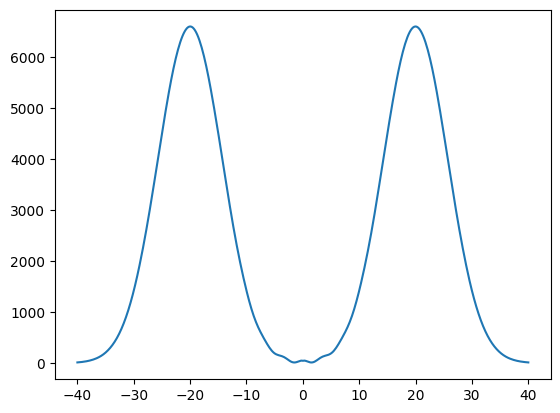

In [118]:
plt.plot(xs, np.abs(np.sum(pos, axis=1)) ** 2)

In [123]:
print((time_evolution(ps, 1).reshape(-1, len(ps))).shape)
print(pos.reshape(len(xs), -1).shape)
pos = pos.reshape(len(xs), -1)

(1, 250)
(400, 250)


In [125]:
psi1 = np.array([(np.sum(pos * time_evolution(ps, t).reshape(-1, len(ps)), axis=1)) * dp for t in ts])

In [124]:
psi1.shape

(100, 400)

## Animation 1

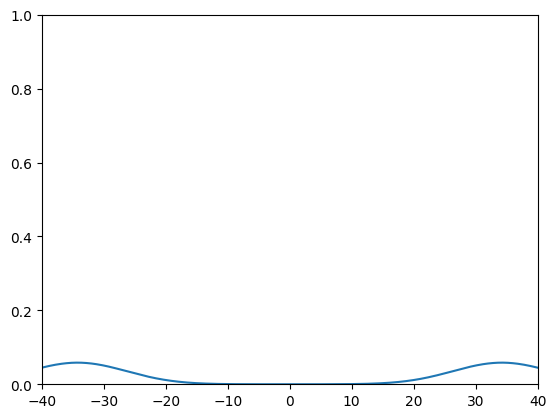

In [126]:
import matplotlib.animation as animation
plt.rcParams["animation.html"] = "jshtml"

i = 0
fig, ax = plt.subplots()
line = ax.plot(xs, np.abs(psi1[i]) ** 2)[0]
ax.set(xlim=[-40, 40], ylim=[0, 1])

num = 1000

def update(frame):
    global i
    # update the line plot:
    i += 1
    line.set_ydata(np.abs(psi1[i]) ** 2)
    return line


ani = animation.FuncAnimation(fig=fig, func=update, frames=60, interval=30)
ani